Step 1: Upload and explore the data

In [15]:
import pandas as pd
import numpy as np

#to display the data 
import matplotlib.pyplot as plt
import seaborn as sns 

DATA_PATH = '../../data/mixed_population_dataset_160_households.csv'
print(f"Reading data from {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

#Style setting for the graphs
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)




Reading data from ../../data/mixed_population_dataset_160_households.csv


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1382400 entries, 0 to 1382399
Data columns (total 4 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   timestamp      1382400 non-null  object 
 1   consumption_l  1382400 non-null  float64
 2   is_leak        1382400 non-null  int64  
 3   household_id   1382400 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 42.2+ MB


In [17]:
df.describe()

,consumption_l,is_leak
count,1.382400e+06,1.382400e+06
mean,4.485368e+00,2.083333e-03
std,1.209474e+01,4.559599e-02
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,2.121889e-01,0.000000e+00
75%,4.068171e+00,0.000000e+00
max,3.290835e+02,1.000000e+00


In [19]:
print(df['is_leak'].value_counts(normalize=True))

is_leak
0    0.997917
1    0.002083
Name: proportion, dtype: float64



Generating a graph with the total consumption along the time


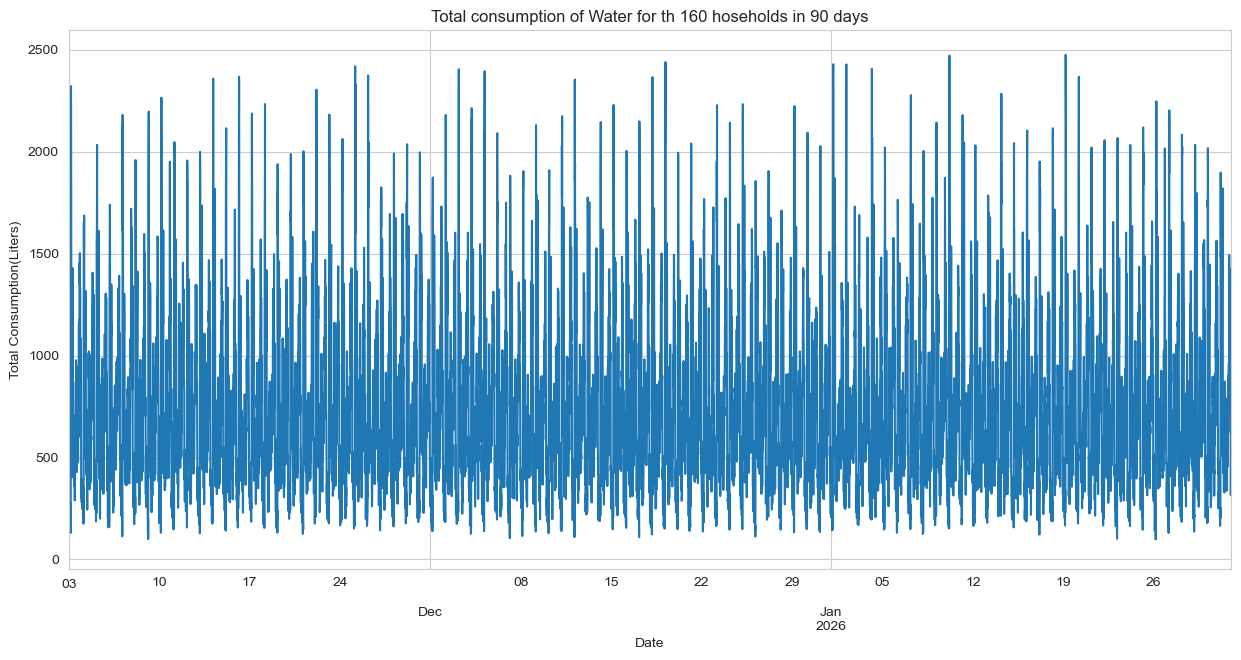

In [20]:
#Visualization of the total consumption
#First converting the column to a timestamp type
df['timestamp'] = pd.to_datetime(df['timestamp'])

#Group the data by the timestamp, sum the consumption of the 160 hoseholds for each 15min interval
total_consumption_over_time = df.groupby('timestamp')['consumption_l'].sum()

print(f"\nGenerating a graph with the total consumption along the time")

plt.figure()
total_consumption_over_time.plot(title='Total consumption of Water for th 160 hoseholds in 90 days')
plt.ylabel('Total Consumption(Liters)')
plt.xlabel('Date')
plt.show()

In [21]:
#Extracting the hour and all from the timestamp
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_of_month'] = df['timestamp'].dt.day
df['week_of_year'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['month'] = df['timestamp'].dt.month


#Create a binary feature yes or no
df['is_weekend'] = (df['day_of_week'] >=5).astype(int)



In [22]:
print(df.head())

            timestamp  consumption_l  is_leak  \
0 2025-11-03 00:00:00       2.185477        0   
1 2025-11-03 00:15:00       0.000000        0   
2 2025-11-03 00:30:00       0.000000        0   
3 2025-11-03 00:45:00       0.000000        0   
4 2025-11-03 01:00:00       0.000000        0   

                      household_id  hour  day_of_week  day_of_month  \
0  household_apartment_family_4855     0            0             3   
1  household_apartment_family_4855     0            0             3   
2  household_apartment_family_4855     0            0             3   
3  household_apartment_family_4855     0            0             3   
4  household_apartment_family_4855     1            0             3   

   week_of_year  month  is_weekend  
0            45     11           0  
1            45     11           0  
2            45     11           0  
3            45     11           0  
4            45     11           0  
